# Modelo de aprendizado não supervisionado
Este notebook demonstra um exemplo simples de aprendizado não supervisionado usando KMeans em um conjunto de dados de amostra.

Tamanho do conjunto de dados: (150, 4)
Primeiras linhas do conjunto de dados:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
Rótulos de cluster gerados pelo KMeans:
(array([0, 1, 2], dtype=int32), array([39, 50, 61]))


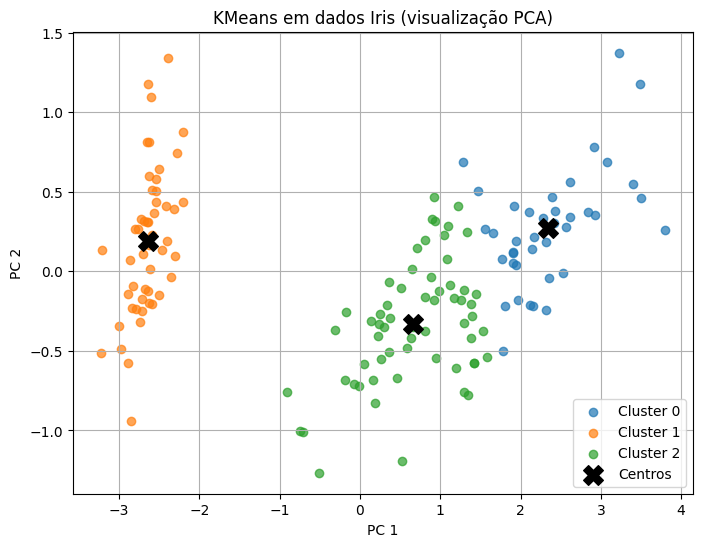

In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Carregar conjunto de dados Iris (sem usar os rótulos para treinar)
iris = load_iris()
X = iris.data

# Criar e treinar o modelo KMeans
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(X)
labels = kmeans.labels_
centers = kmeans.cluster_centers_

# Projetar os dados em 2D para visualização
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
centers_pca = pca.transform(centers)

# Exibir resultados
df = pd.DataFrame(X, columns=iris.feature_names)
print('Tamanho do conjunto de dados:', df.shape)
print('Primeiras linhas do conjunto de dados:')
print(df.head())
print('Rótulos de cluster gerados pelo KMeans:')
print(np.unique(labels, return_counts=True))

plt.figure(figsize=(8, 6))
for cluster in range(n_clusters):
    mask = labels == cluster
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Cluster {cluster}', alpha=0.7)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], s=200, c='black', marker='X', label='Centros')
plt.title('KMeans em dados Iris (visualização PCA)')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend()
plt.grid(True)
plt.show()
